### **Ozempic YouTube Data Scraping & Analysis**

Ozempic (semaglutide) has become one of the most talked-about pharmaceutical products in recent years, transcending its original use as a Type 2 diabetes treatment to become a cultural phenomenon driven heavily by social media and YouTube content. This project collects and analyzes public YouTube data around 
Ozempic to understand how the product is being marketed, discussed, and perceived by the general public.

Using the YouTube Data API, I fetch videos and comments related to Ozempic,extract engagement metrics, and where comments contain URLs, fetch and extract 
the linked web content using BeautifulSoup, giving a richer picture of what information people are sharing and consuming alongside this product.

[YouTube API documentation](https://developers.google.com/youtube/v3/docs)

### Questions to Answer
- What kind of Ozempic content gets the most engagement on YouTube?
- What are people saying in the comments?
- What external links are being shared in comment sections?
- What does the broader web content behind those links reveal?

## Part 1: Data Collection

In [2]:
# Imports
import os
import json
import requests
import pandas as pd
from dotenv import load_dotenv

import re
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

# Load API key
load_dotenv()
api_key = os.getenv("API_KEY")

In [2]:
# suppress warnings
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

**1: Fetch Ozempic Videos**  
Search YouTube for Ozempic related videos and collect metadata including
title, channel, views, likes, and comment count.

In [3]:
url = "https://www.googleapis.com/youtube/v3/search"

params = {
    "q": "Ozempic",
    "part": "snippet",
    "type": "video",
    "maxResults": 50,
    "order": "viewCount",
    "key": api_key
}

response = requests.get(url, params=params)
data = response.json()

# Extract video details
videos = []
for item in data["items"]:
    videos.append({
        "video_id": item["id"]["videoId"],
        "title": item["snippet"]["title"],
        "channel": item["snippet"]["channelTitle"],
        "published_at": item["snippet"]["publishedAt"],
        "description": item["snippet"]["description"]
    })

df_videos = pd.DataFrame(videos)
df_videos.head()

,video_id,title,channel,published_at,description
0,GbE0uQPS81s,Ozempic💉#karanjohar #kapilsharma #ramkapoor #o...,The Untold Edits,2025-05-05T09:30:08Z,Ozempic #karanjohar #kapilsharma #ramkapoor #o...
1,i_jkfSpg6fQ,How Ozempic Works? (3D) by Professor Of How,Professor Of How,2025-07-23T06:14:45Z,
2,_rXANcA01C0,This is what happens when you stop taking Ozempic,Good Morning America,2023-02-01T17:23:34Z,Dr. Jen Ashton weighs in on the popular diabet...
3,I9UVBEZN69k,The effects of Ozempic and other weight loss i...,60 Minutes Australia,2024-02-11T10:45:00Z,A deep dive into the science and the effects -...
4,q3orIN6J-fg,The truth about ozempic #theosbournes #ozzyosb...,The Osbournes,2024-03-28T14:00:38Z,


**2: Fetch Comments**  
Fetching the top comments left by viewers for each video collected.

In [4]:
comments = []

for video_id in df_videos["video_id"]:
    url = "https://www.googleapis.com/youtube/v3/commentThreads"
    params = {
        "videoId": video_id,
        "part": "snippet",
        "maxResults": 100,
        "key": api_key
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if "items" in data:
        for item in data["items"]:
            comment = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id": video_id,
                "author": comment["authorDisplayName"],
                "comment": comment["textDisplay"],
                "likes": comment["likeCount"],
                "published_at": comment["publishedAt"]
            })

df_comments = pd.DataFrame(comments).sort_values(by="likes", ascending=False)
df_comments.head()

,video_id,author,comment,likes,published_at
400,d02j1cBsdDQ,@motivationaldoc,Let’s clear this up: This isn’t just about cut...,10701,2025-07-03T12:33:59Z
4500,kq6bUEieHu0,@edsoncastrooficial,"Para quem está perguntando, sim, sou eu na nar...",2320,2026-05-02T22:35:16Z
2700,hdMWvp3PCQ0,@invierteconpepe_,"Según analistas de Morgan Stanley, las ventas ...",2150,2025-07-13T00:07:56Z
1600,SbFf31gHVjY,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",1724,2025-03-22T22:04:33Z
1800,0YMnHNIuK3M,@TheDiaryOfACEO,"Thank you all for watching, if you could do me...",1206,2024-04-29T07:02:10Z


### Part 2: URL Extraction & Web Content Enrichment
Comments sometimes contain URLs pointing to external articles, news pieces,
or product pages. In this part, URLs are extracted from comments, the linked 
pages are fetched, and relevant content is extracted using BeautifulSoup.

**3: Extract URLs from Comments**

In [5]:
# Extract URLs from comments
url_pattern = re.compile(r'https?://\S+')

url_data = []
for idx, row in df_comments.iterrows():
    urls = url_pattern.findall(row["comment"])
    for url in urls:
        url_data.append({
            "video_id": row["video_id"],
            "author": row["author"],
            "comment": row["comment"],
            "external_url" : url
        })

df_urls = pd.DataFrame(url_data)
print(f"Found {len(df_urls)} URLs across all comments")
df_urls.head()

Found 92 URLs across all comments


,video_id,author,comment,external_url
0,SbFf31gHVjY,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",https://www.youtube.com/watch?v=SbFf31gHVjY&am...
1,SbFf31gHVjY,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",https://www.youtube.com/watch?v=SbFf31gHVjY&am...
2,laPaezEsteI,@Vox,There&#39;s a lot about Ozempic we didn&#39;t ...,https://www.vox.com/science-and-health/2358467...
3,4qc8zX2NrWo,@PatriciaElias,"Quem já fez a BEBIDA SECA BARRIGA: <a href=""ht...","https://www.youtube.com/watch?v=GeUW2S8xT90"">h..."
4,7VO4rlbr8_U,@CienciaTodoDia,👕 Aproveite até 30% de DESCONTO nas camisetas ...,"https://bit.ly/useLoos"">https://bit.ly/useLoos..."


**4: Fetch & Extract Linked Page Content**

In [7]:
def fetch_page_content(url):
    try:
        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        
        title = soup.title.string if soup.title else "No title found"
        meta = soup.find("meta", attrs={"name": "description"})
        description = meta["content"] if meta else "No description found"
        
        return title, description
    except:
        return "Failed to fetch", "Failed to fetch"

# Apply to all URLs
df_urls["page_title"] = None
df_urls["page_description"] = None

for idx, row in tqdm(df_urls.iterrows(), total=len(df_urls),  bar_format='{l_bar}{bar}'):
    title, description = fetch_page_content(row["external_url"])
    df_urls.at[idx, "page_title"] = title
    df_urls.at[idx, "page_description"] = description

df_urls.head()

  0%|          

,video_id,author,comment,external_url,page_title,page_description
0,SbFf31gHVjY,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",https://www.youtube.com/watch?v=SbFf31gHVjY&am...,What Ozempic & Weight Loss Drugs Really Do to ...,***Want more information on visiting the lab!?...
1,SbFf31gHVjY,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",https://www.youtube.com/watch?v=SbFf31gHVjY&am...,What Ozempic & Weight Loss Drugs Really Do to ...,***Want more information on visiting the lab!?...
2,laPaezEsteI,@Vox,There&#39;s a lot about Ozempic we didn&#39;t ...,https://www.vox.com/science-and-health/2358467...,No title found,No description found
3,4qc8zX2NrWo,@PatriciaElias,"Quem já fez a BEBIDA SECA BARRIGA: <a href=""ht...","https://www.youtube.com/watch?v=GeUW2S8xT90"">h...",Faça essa BEBIDA Natural para Emagrecer Rápido...,Desinche a barriga e Acelere o metabolismo com...
4,7VO4rlbr8_U,@CienciaTodoDia,👕 Aproveite até 30% de DESCONTO nas camisetas ...,"https://bit.ly/useLoos"">https://bit.ly/useLoos...",Bitly | Page Not Found | 404,No description found


### Part 3: Analysis & Insights 
With the data collected and enriched, this part explores patterns across 
videos and comments to extract meaningful insights about how Ozempic is 
being discussed and what external content people are sharing.

**5: Video Engagement Overview**  
Looking at which videos generated the most comments and what channels 
are driving the Ozempic conversation.

In [8]:
# Most commented videos
print("Top 10 videos by comment count:")
df_comments.groupby("video_id")["comment"].count().sort_values(ascending=False).head(10)

Top 10 videos by comment count:


video_id
-qDwVhpxwQs    100
0KOJ0oUSV00    100
0YMnHNIuK3M    100
2jhuVDCC_Tg    100
4kT17etStrM    100
4qc8zX2NrWo    100
7VO4rlbr8_U    100
8qEPPnxJRQI    100
8wiA0fpnivE    100
91WBBlGtNdg    100
Name: comment, dtype: int64

100 was the maximum number of comments set due to API limitation.

In [9]:
# Match video_id back to title
video_comment_counts = df_comments.groupby("video_id")["comment"].count().reset_index()
video_comment_counts.columns = ["video_id", "comment_count"]
df_video_insights = df_videos.merge(video_comment_counts, on="video_id")
df_video_insights[["title", "channel", "comment_count"]].sort_values(by="comment_count", ascending=False).head(10)

,title,channel,comment_count
0,Ozempic💉#karanjohar #kapilsharma #ramkapoor #o...,The Untold Edits,100
1,How Ozempic Works? (3D) by Professor Of How,Professor Of How,100
2,This is what happens when you stop taking Ozempic,Good Morning America,100
3,The truth about ozempic #theosbournes #ozzyosb...,The Osbournes,100
4,Eat 1 Teaspoon Before Bed — Melts Belly Fat Li...,motivationaldoc,100
5,I’m a Pathologist: The &quot;Biological Cost&q...,"Dr. Amin Hedayat, MD",100
6,How Ozempic Helps With Weight Loss 😮,Zack D. Films,100
7,Celebs Whose ‘Ozempic Face’ Gave Away The Drug...,MEAWW,100
8,Baby Ozempic,Caroline Baniewicz,100
9,They took Ozempic medicine for weight loss?😰❌#...,tehm,100


**Step 6: Most Liked Comments**

In [12]:
df_comments.sort_values(by="likes", ascending=False)[["author","comment","likes"]].head()

,author,comment,likes
400,@motivationaldoc,Let’s clear this up: This isn’t just about cut...,10701
4500,@edsoncastrooficial,"Para quem está perguntando, sim, sou eu na nar...",2320
2700,@invierteconpepe_,"Según analistas de Morgan Stanley, las ventas ...",2150
1600,@theanatomylab,"Hi All! At about <a href=""https://www.youtube....",1724
1800,@TheDiaryOfACEO,"Thank you all for watching, if you could do me...",1206


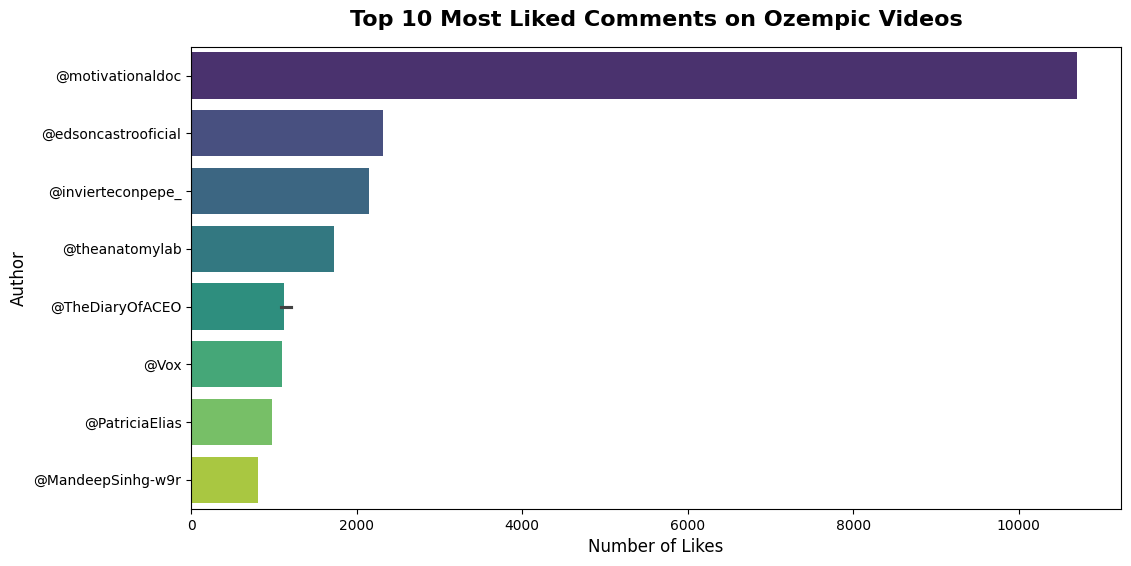

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_comments = df_comments.sort_values(by="likes", ascending=False).head(10).copy()
top_comments["short_author"] = top_comments["author"].str[:20]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_comments,
    x="likes",
    y="short_author",
    palette="viridis",
    ax=ax
)


ax.set_title("Top 10 Most Liked Comments on Ozempic Videos", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Number of Likes", fontsize=12)
ax.set_ylabel("Author", fontsize=12)

plt.show()

### Step 7: External Links Analysis  
Examining what external content people are sharing in Ozempic discussions.

In [21]:
# Most common domains being shared
df_urls["domain"] = df_urls["external_url"].apply(
    lambda x: re.findall(r'https?://(?:www\.)?([^/]+)', x)[0] if re.findall(r'https?://(?:www\.)?([^/]+)', x) else "unknown"
)

df_urls["domain"].value_counts().head(10)

domain
youtube.com             82
vox.com                  1
bit.ly                   1
podcasts.apple.com       1
pazar.evrimagaci.org     1
kreosus.com              1
evrimagaci.org           1
life.so                  1
1.mg                     1
b.ch                     1
Name: count, dtype: int64

### Step 8: Most Active & Influential Commenters  
Identifying the most active and influential commenters in Ozempic discussions,
revealing potential super-spreaders of information or repeated promoters of 
specific content. Cross-referencing commenters against video channel owners 
to distinguish organic commenters from channel owners commenting on their 
own or others content.

In [30]:
# Group by author
commenter_stats = df_comments.groupby("author").agg(
    comment_count=("comment", "count"),
    total_likes=("likes", "sum")
).sort_values(by="total_likes", ascending=False).reset_index()

# Normalize both sides for comparison by stripping @ and lowercasing
channel_owners_normalized = [name.lower().strip() for name in df_videos["channel"].unique()]

commenter_stats["is_channel_owner"] = commenter_stats["author"].apply(
    lambda x: "Yes" if x.lower().strip().lstrip("@") in channel_owners_normalized else "No"
)

print("Top 10 Commenters by Total Likes:")
commenter_stats.head(10)

Top 10 Commenters by Total Likes:


,author,comment_count,total_likes,is_channel_owner
0,@motivationaldoc,1,10701,Yes
1,@TheDiaryOfACEO,3,3371,No
2,@edsoncastrooficial,1,2320,No
3,@invierteconpepe_,1,2150,No
4,@theanatomylab,1,1724,No
5,@Vox,1,1095,Yes
6,@PatriciaElias,1,977,No
7,@MandeepSinhg-w9r,1,809,No
8,@CienciaTodoDia,1,321,No
9,@AnshulGuptaMD,1,288,No


In [23]:
commenter_stats["is_channel_owner"].value_counts()

is_channel_owner
No    4558
Name: count, dtype: int64

In [31]:
# Separate channel owners from organic commenters
channel_owner_commenters = commenter_stats[commenter_stats["is_channel_owner"] == "Yes"]
organic_commenters = commenter_stats[commenter_stats["is_channel_owner"] == "No"]

print(f"Channel owners found commenting: {len(channel_owner_commenters)}")
print(f"Organic commenters: {len(organic_commenters)}\n")


Channel owners found commenting: 2
Organic commenters: 4556



### **Conclusion**  


**Video Engagement Patterns**  
Ozempic content on YouTube spans a wide spectrum, from short medical explainers 
and major news segments to celebrity commentary and unverified weight loss advice. 

**Public Sentiment in Comments**  
The most liked comments tended to carry authority or counter-narratives, with the 
highest liked comment receiving over 10,000 likes from a medical professional 
correcting misconceptions about the drug. The presence of a highly liked Portuguese 
comment highlights that Ozempic interest extends well beyond English-speaking audiences.

**External Link Sharing**  
Only 92 out of 4,500 comments contained URLs, a notably low proportion suggesting 
that Ozempic discussions remain largely conversational rather than reference-driven. 
The majority of shared links pointed back to YouTube itself, while the small number 
of external domains included news outlets, science portals, and commercial weight 
loss pages, with several links returning errors or leading to spam.

**Limitations & Future Work**  
The YouTube API cap of 100 comments per video limits the depth of commenter 
analysis. URL enrichment was constrained by timeouts, and broken links.
Future work could incorporate NLP and sentiment analysis to surface deeper themes across the 
comment data, and pagination to collect beyond the 100 comment limit per video.